In [121]:
import pandas as pd
df=pd.read_csv('/content/Real estate.csv')
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [122]:
df = df.rename(columns={
    "X1 transaction date": "Transaction Date",
    "X2 house age": "House Age",
    "X3 distance to the nearest MRT station": "Distance to MRT",
    "X4 number of convenience stores": "Stores",
    "X5 latitude": "Latitude",
    "X6 longitude": "Longitude",
    "Y house price of unit area": "Price"
})

In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   No                414 non-null    int64  
 1   Transaction Date  414 non-null    float64
 2   House Age         414 non-null    float64
 3   Distance to MRT   414 non-null    float64
 4   Stores            414 non-null    int64  
 5   Latitude          414 non-null    float64
 6   Longitude         414 non-null    float64
 7   Price             414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


In [124]:
df.describe()

,No,Transaction Date,House Age,Distance to MRT,Stores,Latitude,Longitude,Price
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,207.500000,2013.148971,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,119.655756,0.281967,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,1.000000,2012.667000,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,104.250000,2012.917000,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,207.500000,2013.167000,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,310.750000,2013.417000,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,414.000000,2013.583000,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


In [125]:
df.drop(columns=['No'], inplace=True, errors='ignore')
df.head()

,Transaction Date,House Age,Distance to MRT,Stores,Latitude,Longitude,Price
0,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [126]:
from sklearn.model_selection import train_test_split
X = df[['Transaction Date','House Age','Distance to MRT','Stores','Latitude', 'Longitude']]
Y = df['Price']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y ,test_size=0.20, random_state=42)

In [127]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [128]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, Y_train)

LinearRegression()

In [129]:
y_pred = model.predict(X_test_scaled)

from sklearn.metrics import mean_squared_error
mse = mean_squared_error(Y_test, y_pred)

print("MSE:", mse)
from sklearn.metrics import r2_score

r2 = r2_score(Y_test, y_pred)
print("R2 Score:", r2)

MSE: 53.505619124502054
R2 Score: 0.6810580555095946


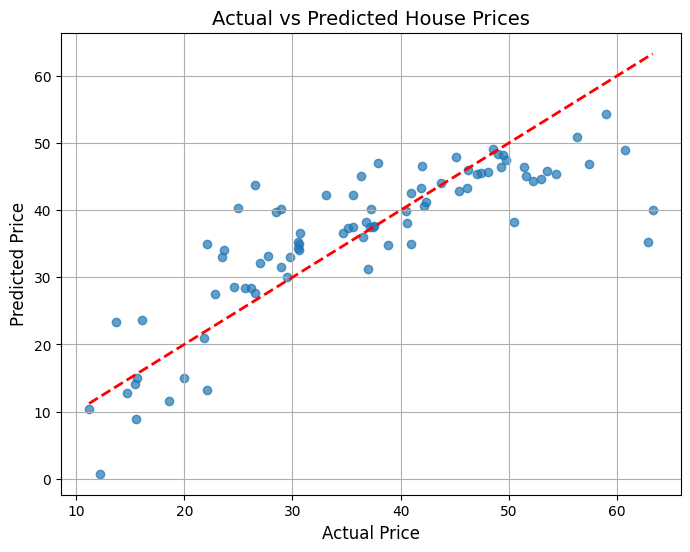

In [130]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,6))
plt.scatter(Y_test, y_pred, alpha=0.7)
plt.plot([Y_test.min(), Y_test.max()],
         [Y_test.min(), Y_test.max()],
         linestyle='--',lw=2,color='red'
         )


plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")


plt.grid(True)

plt.show()